Typical workflow creating a model


In [1]:
workflows= {
    1: 'get data ready (turn into tensors)',
    2: ['build or pick a trained model', 'pick loss function and optimizer', 'build training loop'], 
    3: 'fit the model and predict',
    4: 'evaluate the model',
    5: 'improve model',
    6: 'save and reload model'
}

In [2]:
def show_workflow(workflows= workflows):
    for a, b in workflows.items():

        print(a, b)

show_workflow()

1 get data ready (turn into tensors)
2 ['build or pick a trained model', 'pick loss function and optimizer', 'build training loop']
3 fit the model and predict
4 evaluate the model
5 improve model
6 save and reload model


In [3]:
import torch
from torch import nn
import matplotlib.pyplot as plt

PREPARING AND LOADING DATA

In [4]:
# creatnig parameters

weight= 0.7
bias= 0.3

#data

start= 0
end= 1
step= 0.01
X= torch.arange(start, end, step).unsqueeze(dim=1)
y= weight * X + bias
X

tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900],
        [0.1000],
        [0.1100],
        [0.1200],
        [0.1300],
        [0.1400],
        [0.1500],
        [0.1600],
        [0.1700],
        [0.1800],
        [0.1900],
        [0.2000],
        [0.2100],
        [0.2200],
        [0.2300],
        [0.2400],
        [0.2500],
        [0.2600],
        [0.2700],
        [0.2800],
        [0.2900],
        [0.3000],
        [0.3100],
        [0.3200],
        [0.3300],
        [0.3400],
        [0.3500],
        [0.3600],
        [0.3700],
        [0.3800],
        [0.3900],
        [0.4000],
        [0.4100],
        [0.4200],
        [0.4300],
        [0.4400],
        [0.4500],
        [0.4600],
        [0.4700],
        [0.4800],
        [0.4900],
        [0.5000],
        [0.5100],
        [0.5200],
        [0.5300],
        [0.5400],
        [0

In [5]:
print(len(X), len(y))

100 100


SPLITTING DATA INTO TRAIN VALID TEST

In [6]:
from sklearn.model_selection import train_test_split

X_train, temp_X, y_train, temp_y= train_test_split(X, y, test_size=0.30, random_state=0)


X_valid, X_test, y_valid, y_test= train_test_split(temp_X, temp_y, test_size=0.50, random_state=0)

In [7]:
print(len(X_train), len(X_valid), len(X_test), len(y_train), len(y_valid), len(y_test))

70 15 15 70 15 15


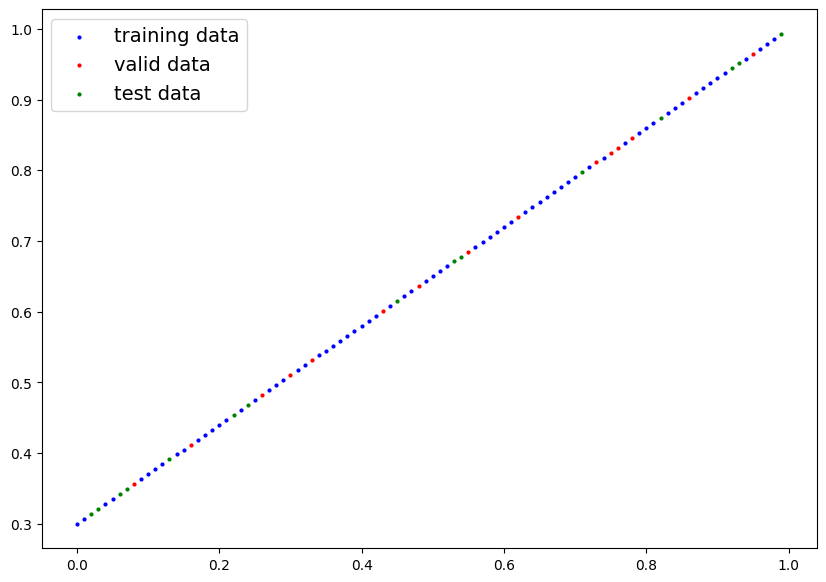

In [8]:
def plot_predictions(
        train_data= X_train,
        train_labels= y_train,
        valid_data= X_valid,
        valid_labels= y_valid,
        test_data= X_test,
        test_labels= y_test,
        prediction= None):
    '''Plots traning, valid and test data'''
    
    plt.figure(figsize=(10, 7))

    plt.scatter(train_data, train_labels, c='b', s=4, label="training data")
    plt.scatter(valid_data, valid_labels, c='r', s=4, label="valid data")
    plt.scatter(test_data, test_labels, c='g', s=4, label="test data")
    
    if prediction is not None:
        plt.scatter(test_data, prediction, c='y', s=4, label='predictions')

    plt.legend(prop= {'size': 14})
    

plot_predictions()

Building model

In [47]:

class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

        self.bias= nn.Parameter( torch.randn(1, requires_grad=True, dtype=torch.float))


    def forward(self, x: torch.Tensor) -> torch.Tensor: 
        return self.weight * x + self.bias


1. torch.nn.Parameter - vilka parameter vår modell ska använda / layers?
2. torch.optim - pytorchs opimizers

In [48]:
SEED=0

torch.manual_seed(SEED)
model=LinearRegression()

print(list(model.parameters()))


#samma:

print(model.state_dict())

[Parameter containing:
tensor([1.5410], requires_grad=True), Parameter containing:
tensor([-0.2934], requires_grad=True)]
OrderedDict({'weight': tensor([1.5410]), 'bias': tensor([-0.2934])})


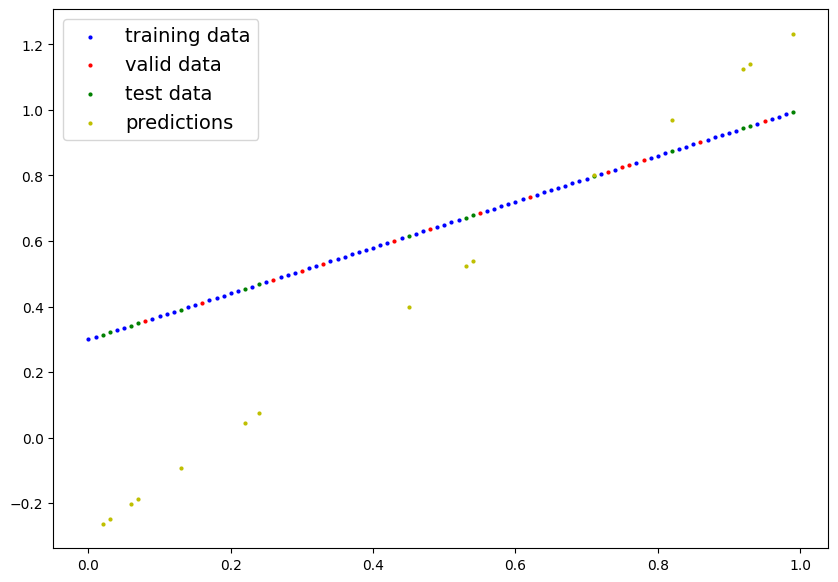

In [ ]:
with torch.inference_mode(): #viktigt att använda när man gör eval, stänger av gradient som uppdaterar weight
    y_preds = model(X_test)

plot_predictions(prediction=y_preds)

 ett sätt att mäta hur fel vår model har är vi en lossfunction
 Kan även kallas för: 
 1. cost function
 2. criterion.

In [ ]:
loss_fn= nn.L1Loss()

optimizer= torch.optim.SGD(params=model.parameters(), lr=0.001) 

Build training and testing loop

1. Loop thru data

2. forward pass

3. calculate loss (comparare forward pass predictions to ground truth labels)

4. optimizer zero grad

5. loss backkwardspass (move backwards thru network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation**))

6. optimizer step (use optimizer to adjust our models parameters to improve loss)

In [ ]:
epochs=1


for epoch in range(epochs):
    
    # 1. set model in training mode
    model.train()

    # 2. forward pass
    y_preds= model(X_train)

    # 3. calculate loss
    loss = loss_fn(y_preds, y_train)

    # 4. opimizer zero grad
    optimizer.zero_grad()

    # 5. perform backpropagation
    loss.backward()

    # 6. step the opimtizer (perform gradient decent)

    optimizer.step()
